In [1]:
import os
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from tqdm import tqdm
import pickle
import seaborn as sns
from scipy.stats import spearmanr
from sklearn.linear_model import LinearRegression

# silence warnings
import warnings
warnings.filterwarnings('ignore')

# binning
try:
    from optbinning import ContinuousOptimalBinning
except:
    ! pip install optbinning
    from optbinning import ContinuousOptimalBinning

(CVXPY) Jan 29 07:25:33 PM: Encountered unexpected exception importing solver GLOP:
RuntimeError('Unrecognized new version of ortools (9.11.4210). Expected < 9.10.0. Please open a feature request on cvxpy to enable support for this version.')
(CVXPY) Jan 29 07:25:33 PM: Encountered unexpected exception importing solver PDLP:
RuntimeError('Unrecognized new version of ortools (9.11.4210). Expected < 9.10.0. Please open a feature request on cvxpy to enable support for this version.')


#### Functions

In [2]:
def bin_feature(col, X, y, str_monotonic_trend):
    # logic for ltv
    str_prebinning_method = 'uniform'
    # init
    cls_binning = ContinuousOptimalBinning(
        name=col,
        dtype='numerical',
        prebinning_method=str_prebinning_method,
        monotonic_trend=str_monotonic_trend,
        user_splits=None, 
        user_splits_fixed=None,
    )
    # fit
    cls_binning.fit(
        X[col],
        y,
    )
    # transform
    str_col = f'{col}_binned'
    X[str_col] = cls_binning.transform(
        X[col],
        metric='mean',
    )
    # return
    return cls_binning, X

#### Constants

In [3]:
str_project = os.getcwd().split('/')[4].replace('_','-')
print(f'Project: {str_project}')

str_task = os.getcwd().split('/')[5]
print(f'Task: {str_task}')

str_subtask = os.getcwd().split('/')[6]
print(f'Subtask: {str_subtask}')

str_target = 'Early_Pay_Delinquency_60_720_Flag'
print(f'Target: {str_target}')

str_dirname_output = './output'

str_task_tmp = '16_60_in_720_chargeoff_dl'

Project: 20241112-simple-model-test
Task: create_grid
Subtask: 04_60_in_720_chargeoff_dl
Target: Early_Pay_Delinquency_60_720_Flag


#### Output directory

In [4]:
try:
    os.mkdir(str_dirname_output)
except:
    pass

#### Import data

In [5]:
list_cols = [
    str_target,
    'bitdebtor',
    'ENG-loan_to_value',
]
list_str_df = [
    'train',
    'test',
    'holdout',
]
list_df = []
for str_df in tqdm(list_str_df):
    str_filename = f'df_{str_df}.gzip'
    str_uri = f's3://{str_project}/{str_task_tmp}/01_data_split/{str_filename}'
    df = pd.read_parquet(
        str_uri,
        columns=list_cols,
    )
    list_df.append(df)
df = pd.concat(list_df)
df = df[df['bitdebtor'] == 1].copy()
int_nrows = df.shape[0]
# show
df

100%|██████████| 3/3 [00:02<00:00,  1.32it/s]


,Early_Pay_Delinquency_60_720_Flag,bitdebtor,ENG-loan_to_value
1,0.315976,1,1.432368
12,0.622037,1,1.087884
31,0.946602,1,1.433137
45,0.167439,1,1.222982
46,0.010043,1,1.206549
...,...,...,...
41673,0.880849,1,1.100414
41676,0.668406,1,1.530976
41684,0.471789,1,1.405987
41692,0.955819,1,1.246665


#### Plots

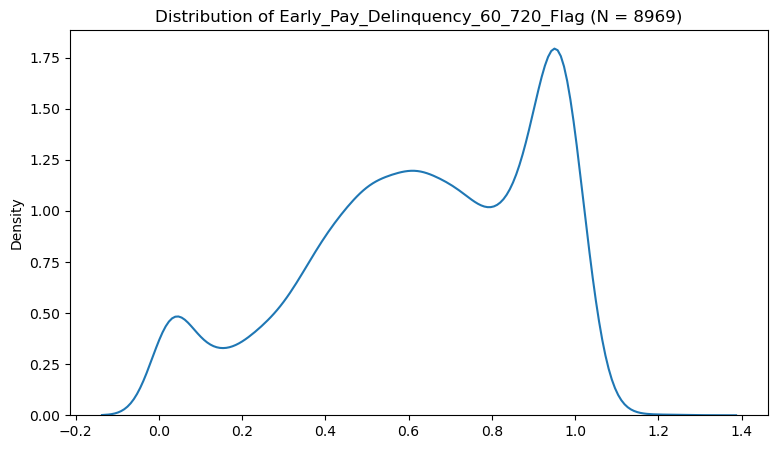

In [7]:
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title(f'Distribution of {str_target} (N = {int_nrows})')
sns.kdeplot(list(df[str_target]), ax=ax)
plt.show()

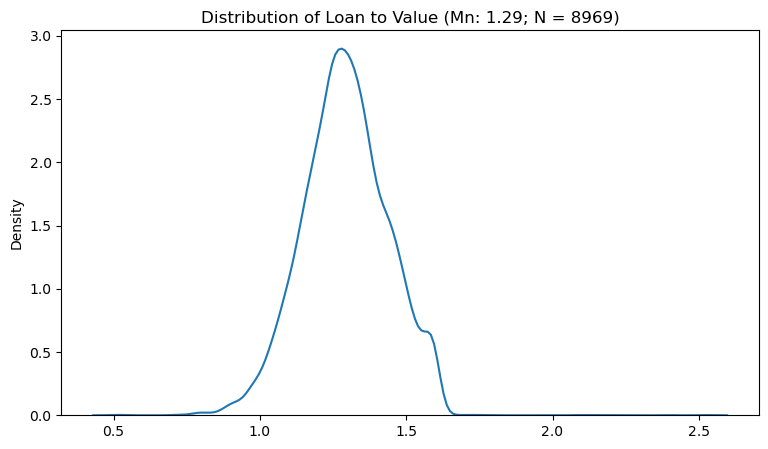

In [8]:
flt_mn = df['ENG-loan_to_value'].mean()
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title(f'Distribution of Loan to Value (Mn: {flt_mn:0.2f}; N = {int_nrows})')
sns.kdeplot(list(df['ENG-loan_to_value']), ax=ax)
plt.show()

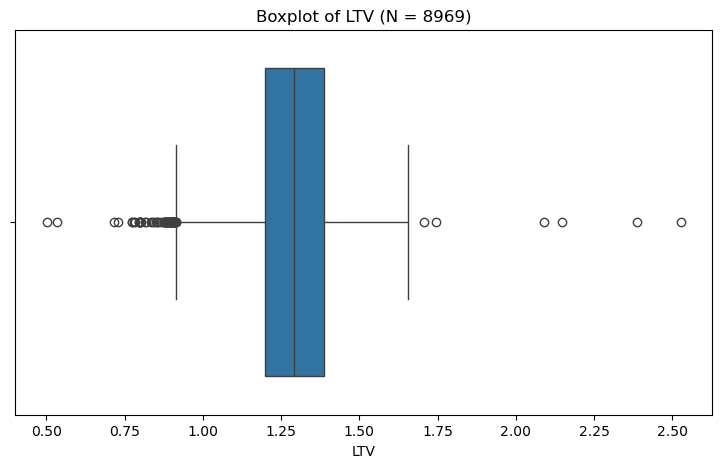

In [9]:
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title(f'Boxplot of LTV (N = {int_nrows})')
ax.set_xlabel('LTV')
sns.boxplot(x=df['ENG-loan_to_value'], ax=ax)
# show
plt.show()

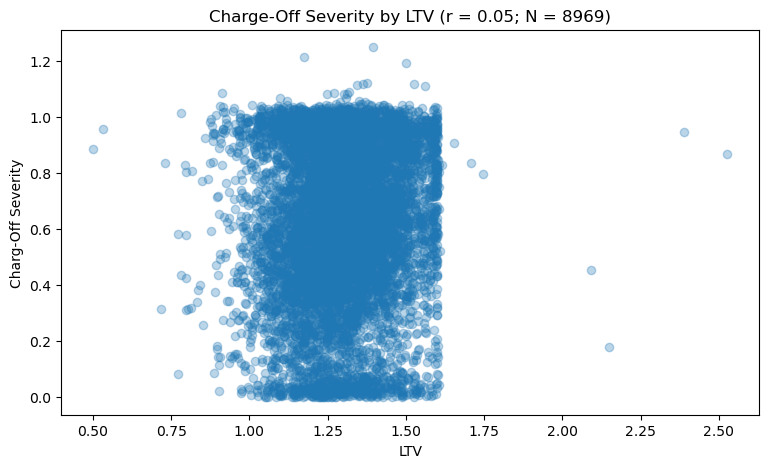

In [10]:
x = df['ENG-loan_to_value']
y = df[str_target]
flt_r = spearmanr(x, y)[0]
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title(f'Charge-Off Severity by LTV (r = {flt_r:0.2f}; N = {int_nrows})')
ax.set_xlabel('LTV')
ax.set_ylabel('Charg-Off Severity')
ax.scatter(x, y, alpha=0.3)
plt.show()

#### Make bin

In [11]:
cls_binner, df = bin_feature(
    col='ENG-loan_to_value',
    X=df[list_cols].copy(),
    y=df[str_target],
    str_monotonic_trend='ascending',
)
# show
df

,Early_Pay_Delinquency_60_720_Flag,bitdebtor,ENG-loan_to_value,ENG-loan_to_value_binned
1,0.315976,1,1.432368,0.653603
12,0.622037,1,1.087884,0.605262
31,0.946602,1,1.433137,0.653603
45,0.167439,1,1.222982,0.635684
46,0.010043,1,1.206549,0.615474
...,...,...,...,...
41673,0.880849,1,1.100414,0.605262
41676,0.668406,1,1.530976,0.663706
41684,0.471789,1,1.405987,0.645319
41692,0.955819,1,1.246665,0.635684


#### Show bins

In [12]:
df_bins = cls_binner.binning_table.build()
df_bins = df_bins[~df_bins['Bin'].isin(['Special','Missing',''])].copy()
df_bins['bin_number'] = range(1, df_bins.shape[0]+1)
df_bins['minimum'] = df_bins['Bin'].apply(
    lambda x: float(x.split(', ')[0].replace('(','').replace('[','')),
)
df_bins['maximum'] = df_bins['Bin'].apply(
    lambda x: float(x.split(', ')[1].replace(')','')),
)
df_bins['minimum'] = df_bins['minimum'].clip(lower=0)
df_bins['maximum'] = df_bins['maximum'].clip(upper=df['ENG-loan_to_value'].max())
# label
df_bins['label'] = df_bins.apply(
    lambda x: f'{x["minimum"]:0.2f} - {x["maximum"]:0.2f}',
    axis=1,
)
# show
df_bins

,Bin,Count,Count (%),Sum,Std,Mean,Min,Max,Zeros count,WoE,IV,bin_number,minimum,maximum,label
0,"(-inf, 0.80)",14,0.001561,8.374668,0.280931,0.598191,8.134673e-02,1.013230,0,-0.037632,0.000059,1,0.00,0.800000,0.00 - 0.80
1,"[0.80, 1.11)",866,0.096555,524.156615,0.30585,0.605262,1.236392e-03,1.085710,0,-0.030561,0.002951,2,0.80,1.110000,0.80 - 1.11
2,"[1.11, 1.21)",1595,0.177835,981.681374,0.290901,0.615474,2.151406e-18,1.214714,0,-0.020348,0.003619,3,1.11,1.210000,1.11 - 1.21
3,"[1.21, 1.31)",2530,0.282083,1608.280031,0.279067,0.635684,4.044146e-18,1.085927,0,-0.000139,0.000039,4,1.21,1.310000,1.21 - 1.31
4,"[1.31, 1.41)",2101,0.234251,1355.814884,0.272599,0.645319,6.432594e-04,1.249921,0,0.009496,0.002225,5,1.31,1.410000,1.31 - 1.41
5,"[1.41, 1.51)",1248,0.139146,815.696559,0.265828,0.653603,1.065628e-17,1.193999,0,0.017781,0.002474,6,1.41,1.510000,1.41 - 1.51
6,"[1.51, 1.61)",607,0.067678,402.869365,0.274824,0.663706,2.309954e-03,1.120269,0,0.027883,0.001887,7,1.51,1.610000,1.51 - 1.61
7,"[1.61, 2.43)",7,0.000780,4.947401,0.261486,0.706772,1.796339e-01,0.945551,0,0.070949,0.000055,8,1.61,2.430000,1.61 - 2.43
8,"[2.43, inf)",1,0.000111,0.870332,0.0,0.870332,8.703323e-01,0.870332,0,0.234510,0.000026,9,2.43,2.526389,2.43 - 2.53


#### Plot

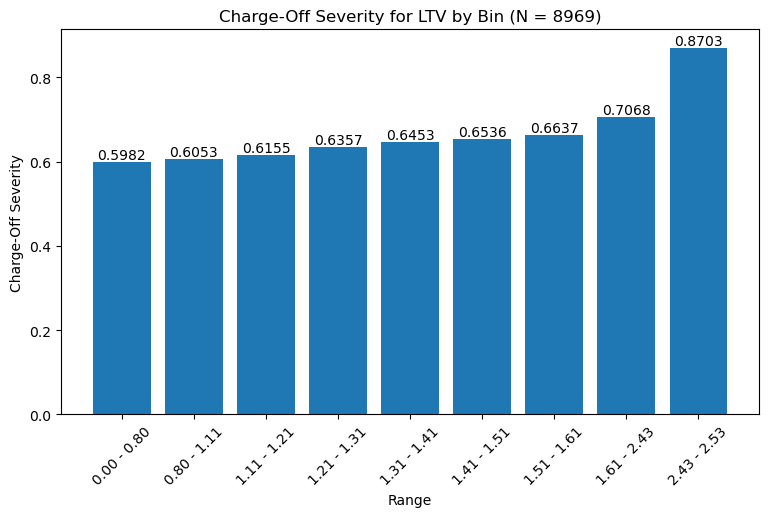

In [14]:
fig, ax = plt.subplots(figsize=(9,5))
ax.set_title(f'Charge-Off Severity for LTV by Bin (N = {int_nrows})')
ax.set_xlabel('Range')
ax.set_ylabel('Charge-Off Severity')
bars = ax.bar(df_bins['label'], df_bins['Mean'])
ax.bar_label(bars, fmt='%.4f')
ax.set_xticklabels(df_bins['label'], rotation=45)

# save
str_filename = 'plt_bins_original.png'
str_local_path =  f'{str_dirname_output}/{str_filename}'
plt.savefig(str_local_path, bbox_inches='tight')

# show
plt.show()

#### Make dictionary

In [15]:
dict_ltv_bins = dict(zip(df_bins['maximum'], df_bins['Mean']))
dict_ltv_bins = {key: (0.01 if val == 0 else val) for key, val in dict_ltv_bins.items()}

# save
str_filename = 'dict_bins_ltv.pkl'
str_local_path = f'{str_dirname_output}/{str_filename}'
pickle.dump(dict_ltv_bins, open(str_local_path, 'wb'))

# show
dict_ltv_bins

{0.8: 0.5981905993444799,
 1.11: 0.6052616798997871,
 1.21: 0.6154742159583763,
 1.31: 0.6356838066052604,
 1.41: 0.6453188404962024,
 1.51: 0.6536030123642623,
 1.61: 0.6637057085458945,
 2.43: 0.7067715717469841,
 2.526389: 0.8703323201613054}